# Single-qubit $Y(\pi)$: Gaussian vs. Gaussian+DRAG vs. Optimized

$Y(\pi)$ is the $X(\pi)$ gate with the drive phase advanced by $\pi/2$ — an **exact**
frame rotation of the three-level model, noise channels included (derivation:
`_gatelib/gatespec.py`). So no optimization runs here: every arm is the corresponding
$X(\pi)$ arm, replayed on the rotated quadratures, and every number below must match the
$X(\pi)$ folder's point for point.

That makes this notebook two things: the $Y(\pi)$ waveform deliverable (CSVs an AWG can
play), and a numerical check of the covariance the claim rests on — §5.

Everything below is gate-generic and comes from `proposals/_gatelib`; this folder only
binds the target gate (`armlib.py` -> `gatespec.SPECS["Ypi"]`).
The companion folder `1qb_Gaussian-drag-optimization` holds the reference $X(\pi)$ study
this one mirrors — read its `README.md` first for the method, the evaluation-object rule
and the calibration protocol, which are unchanged here.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, str(Path.cwd()))
import armlib as al

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.facecolor": "white"})

DEV = al.DEV
print(f"target gate = {al.GATE.name}   theta = {al.THETA:.6f} rad   "
      f"axis azimuth = {al.GATE.phi_axis:.6f} rad   solve_mode = {al.GATE.solve_mode}")
print(f"T           = {al.T:g} ns          M = {DEV.n_modes}")
print(f"Delta       = {DEV.delta:.6f} rad/ns   ({DEV.anharmonicity*1e3:+.0f} MHz)")
print(f"Omega_max   = {DEV.rabi_max_rate:.6f} rad/ns    eta = Omega_max/|Delta| = {DEV.eta:.3f}")
print(f"design eps  = {DEV.control_error:.1%}      design delta_z = {DEV.static_detuning*1e3:.1f} MHz rms")
print(f"decoh floor = {DEV.decoherence_floor:.4e}   (waveform independent, same for every arm)")
print(f"AWG export  = {al.N_EXPORT} samples @ {DEV.sample_rate} GS/s")
print(f"fluence unit F0 = theta^2/T = {al.FLUENCE_FLOOR:.5f} rad^2/ns")
print(f"arms available  = {al.ARM_ORDER}")

target gate = Y(pi)   theta = 3.141593 rad   axis azimuth = 1.570796 rad   solve_mode = rotate_from_x
T           = 50 ns          M = 20
Delta       = -1.256637 rad/ns   (-200 MHz)
Omega_max   = 0.314159 rad/ns    eta = Omega_max/|Delta| = 0.250
design eps  = 2.0%      design delta_z = 0.1 MHz rms
decoh floor = 4.1667e-04   (waveform independent, same for every arm)
AWG export  = 120 samples @ 2.4 GS/s
fluence unit F0 = theta^2/T = 0.19739 rad^2/ns
arms available  = ('A', 'B', 'C', 'D', 'E', 'F')


## 1. The arms

Same five arms as the $X(\pi)$ study, each wrapped in `RotatedInput`: the design curve
$(\mathbf a,\mathbf c,\Phi_0)$ is untouched, only the played quadratures are rotated,
$(\Omega_x+i\Omega_y)\to e^{i\pi/2}(\Omega_x+i\Omega_y)$.

Consequently $\kappa$, $\tau$ and $C_1,C_2,C_3$ are literally the $X(\pi)$ arm's;
$C_4\sim|\Lambda|^2$ and the peak $|\Omega|$ are rotation invariant. What visibly changes
is only Fig. 1: the drive has moved from $\Omega_x$ into $\Omega_y$.

In [2]:
arms = al.build_arms()
ARM_ORDER = al.ARM_ORDER
for k in ARM_ORDER:
    a = arms[k]
    print(f"{k}  {a.name:18s} layer={a.layer:12s} ||a||={np.linalg.norm(a.a):.4f} "
          f"||c||={np.linalg.norm(a.c):.4e} Phi_0={a.Phi_0:+.4f} run_id={getattr(a, 'run_id', None)}")
    print(f"     {a.note}")

missing = [k for k in al.OPTIMIZED_ARMS if k not in arms]
if missing:
    print(f"\nnot solved yet: {missing}. Everything below runs on the available arms; "
          f"re-run this notebook after the new run_ids land in configs/runs.json.")

A  Gaussian           layer=planar       ||a||=0.1163 ||c||=0.0000e+00 Phi_0=+0.0000 run_id=None
     Truncated Gaussian (sigma=T/6) fitted to M=20 sine modes, c1-projected and rescaled to theta=3.141593. Omega_y == 0: no DRAG, no Stark correction.  Played with the drive phase advanced by phi_axis=1.570796 rad -- exact frame rotation of the corresponding X-axis arm, not an independent solve.
B  Gaussian + DRAG    layer=planar_drag  ||a||=0.1163 ||c||=0.0000e+00 Phi_0=+0.0000 run_id=None
     Truncated Gaussian (sigma=T/6) for theta=3.141593, least-squares fit to M=20 sine modes (relRMS after c1 projection = 8.72e-03), DRAG/Stark readout. The industry baseline.  Played with the drive phase advanced by phi_axis=1.570796 rad -- exact frame rotation of the corresponding X-axis arm, not an independent solve.
C  Optimized (3D)     layer=general      ||a||=0.2860 ||c||=6.3858e-01 Phi_0=+0.4917 run_id=20260808_F06min_gaussian3d_construction
     solve_budget general-layer solution for theta=3.

## Fig. 1 — the control waveforms

Top row: the **played** waveform of each arm at the AWG sampling — what the instrument
would actually emit — with $\pm\Omega_{\max}$ as a dashed ceiling. Arm A's
$\Omega_y\equiv0$ is drawn so B's DRAG quadrature is legible as a difference.

Bottom row: the **design curve** — curvature $\kappa(t)$ (identical for A and B by
construction) and torsion $\tau(t)$ with the R-guard bound drawn in.

★ Watch the printed peak utilisation. It is the headroom the optimizer has, and it is
the one number that changes most between rotation angles.

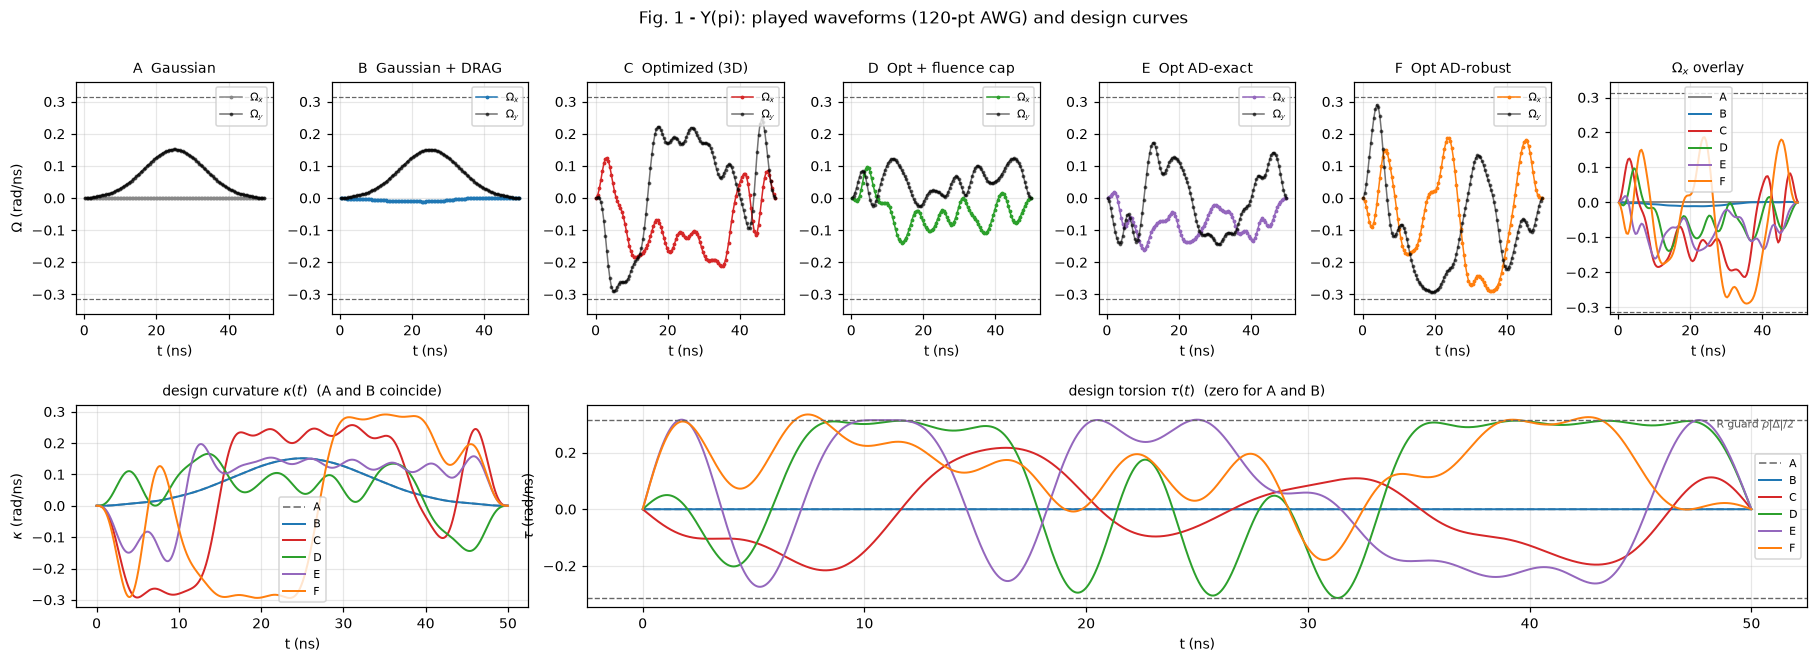

peak utilisation (played |Omega| / Omega_max):
  A:  48.2%


  B:  48.2%
  C:  93.1%
  D:  52.7%
  E:  62.6%
  F:  93.6%


In [3]:
from curve_opt import geometry

t_awg, _ = geometry.midpoint_grid(al.T, al.N_EXPORT)
t_fine, _ = geometry.midpoint_grid(al.T, al.N_DESIGN)

n_arms = len(ARM_ORDER)
fig = plt.figure(figsize=(2.9 * (n_arms + 1), 6.2))
gs = fig.add_gridspec(2, n_arms + 1, height_ratios=[1.15, 1.0], hspace=0.42, wspace=0.30)

for i, k in enumerate(ARM_ORDER):
    ax = fig.add_subplot(gs[0, i])
    ox, oy = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, ".-", ms=3, lw=1.0, color=al.ARM_COLORS[k], label=r"$\Omega_x$")
    ax.plot(t_awg, oy, ".-", ms=3, lw=1.0, color="k", alpha=0.55, label=r"$\Omega_y$")
    for s in (+1, -1):
        ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=9)
    ax.set_xlabel("t (ns)")
    if i == 0:
        ax.set_ylabel(r"$\Omega$ (rad/ns)")
    ax.set_ylim(-1.15 * DEV.rabi_max_rate, 1.15 * DEV.rabi_max_rate)
    ax.legend(fontsize=7, loc="upper right")

ax = fig.add_subplot(gs[0, n_arms])
for k in ARM_ORDER:
    ox, _ = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, lw=1.3, color=al.ARM_COLORS[k], label=k)
for s in (+1, -1):
    ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
ax.set_title(r"$\Omega_x$ overlay", fontsize=9)
ax.set_xlabel("t (ns)")
ax.legend(fontsize=7)

axk = fig.add_subplot(gs[1, :2])
axt = fig.add_subplot(gs[1, 2:])
for k in ARM_ORDER:
    dc = al.design_of(arms[k], al.N_DESIGN)
    ls = "--" if k == "A" else "-"
    axk.plot(t_fine, np.asarray(dc.kappa), ls, lw=1.3, color=al.ARM_COLORS[k], label=k)
    axt.plot(t_fine, np.asarray(dc.tau), ls, lw=1.3, color=al.ARM_COLORS[k], label=k)
axk.set_xlabel("t (ns)"); axk.set_ylabel(r"$\kappa$ (rad/ns)")
axk.set_title(r"design curvature $\kappa(t)$  (A and B coincide)", fontsize=9)
axk.legend(fontsize=7)
guard = 0.5 * abs(DEV.delta) / 2.0
for s in (+1, -1):
    axt.axhline(s * guard, ls="--", lw=0.9, color="0.4")
axt.text(0.99, 0.93, r"R guard $\rho|\Delta|/2$", transform=axt.transAxes,
         ha="right", va="top", fontsize=7, color="0.35")
axt.set_xlabel("t (ns)"); axt.set_ylabel(r"$\tau$ (rad/ns)")
axt.set_title(r"design torsion $\tau(t)$  (zero for A and B)", fontsize=9)
axt.legend(fontsize=7)

fig.suptitle(f"Fig. 1 - {al.GATE.name}: played waveforms ({al.N_EXPORT}-pt AWG) and design curves",
             y=0.985)
plt.show()

print("peak utilisation (played |Omega| / Omega_max):")
for k in ARM_ORDER:
    ox, oy = al.broadcast_of(arms[k], al.N_DESIGN)
    print(f"  {k}: {np.max(np.hypot(ox, oy)) / DEV.rabi_max_rate:6.1%}")

## 2. Table 1 — the noiseless comparison

$C_1,C_2,C_3$ on the **design curve**; the gate residual, $C_4$ and the peak on the
**played** waveform (project red line). Arm A's $C_4$ is computed directly on its played
waveform rather than through `budget.budget_terms`, which would apply the DRAG readout
map to an undragged pulse.

$\Phi_{\rm vz}$ is calibrated once per arm here, at $\delta=\epsilon=0$, and **frozen**
for the whole sweep — what a real experiment does.

The decoherence floor is waveform independent, so it gets its own column and is never
folded in; it cannot change the ranking.

In [4]:
rows = {k: al.characterize(arms[k]) for k in ARM_ORDER}
qchk = {k: al.qutip_cross_check(arms[k]) for k in ARM_ORDER}

tab = pd.DataFrame({
    "arm": [f"{k} {arms[k].name}" for k in ARM_ORDER],
    "C1": [rows[k]["c1"] for k in ARM_ORDER],
    "C2": [rows[k]["c2"] for k in ARM_ORDER],
    "C3": [rows[k]["c3"] for k in ARM_ORDER],
    "C4": [rows[k]["c4"] for k in ARM_ORDER],
    "predicted": [rows[k]["total"] for k in ARM_ORDER],
    "decoh floor": [rows[k]["decoherence_floor"] for k in ARM_ORDER],
    "true (jax)": [rows[k]["baseline_infidelity"] for k in ARM_ORDER],
    "true (QuTiP)": [qchk[k]["infid_qutip"] for k in ARM_ORDER],
    "true/pred": [rows[k]["ratio_true_over_predicted"] for k in ARM_ORDER],
    "leakage": [rows[k]["leakage_population"] for k in ARM_ORDER],
    "peak/Omega_max": [rows[k]["peak_frac"] for k in ARM_ORDER],
    "fluence/F0": [rows[k]["fluence_over_floor"] for k in ARM_ORDER],
    "max|tau|": [rows[k]["max_abs_tau"] for k in ARM_ORDER],
}).set_index("arm")

fmt = {c: "{:.4e}".format for c in tab.columns}
fmt["peak/Omega_max"] = "{:.1%}".format
fmt["fluence/F0"] = "{:.2f}".format
fmt["max|tau|"] = "{:.4f}".format
fmt["true/pred"] = "{:.3e}".format
tab_show = pd.DataFrame({c: [fmt[c](v) for v in tab[c]] for c in tab.columns}, index=tab.index)
print(f"Table 1 - {al.GATE.name}, noiseless (delta = epsilon = 0)")
display(tab_show)

print("jax vs QuTiP cross-check (independent numerics; > 1e-3 relative would be a bug):")
for k in ARM_ORDER:
    print(f"  {k}: jax {qchk[k]['infid_jax']:.6e}   qutip {qchk[k]['infid_qutip']:.6e}"
          f"   rel diff {qchk[k]['rel_diff']:.2e}   (N={qchk[k]['N']})")

best_pred = min(ARM_ORDER, key=lambda k: rows[k]["total"])
best_true = min(ARM_ORDER, key=lambda k: rows[k]["baseline_infidelity"])
print(f"\nlowest predicted budget : {best_pred}   ({rows[best_pred]['total']:.4e})")
print(f"lowest TRUE infidelity  : {best_true}   ({rows[best_true]['baseline_infidelity']:.4e})")

Table 1 - Y(pi), noiseless (delta = epsilon = 0)


,C1,C2,C3,C4,predicted,decoh floor,true (jax),true (QuTiP),true/pred,leakage,peak/Omega_max,fluence/F0,max|tau|
arm,,,,,,,,,,,,,
A Gaussian,1.9555e-05,7.5028e-09,6.5797e-04,6.7428e-06,6.8428e-04,4.1667e-04,1.7185e-03,1.7185e-03,2.511e+00,9.3429e-06,48.2%,1.71,0.0000
B Gaussian + DRAG,1.9555e-05,7.5028e-09,6.5797e-04,3.3007e-09,6.7754e-04,4.1667e-04,7.2317e-06,7.2317e-06,1.067e-02,4.3126e-09,48.2%,1.71,0.0000
C Optimized (3D),1.8943e-13,2.2696e-10,5.9380e-12,1.8580e-10,4.1889e-10,4.1667e-04,1.8086e-04,1.8083e-04,4.318e+05,2.7127e-04,93.1%,10.36,0.2167
D Opt + fluence cap,6.5269e-05,1.0978e-08,3.8606e-04,1.2884e-07,4.5147e-04,4.1667e-04,9.0088e-06,9.0084e-06,1.995e-02,1.3513e-05,52.7%,2.00,0.3130
E Opt AD-exact,4.1245e-05,7.3122e-09,5.1888e-04,4.2192e-05,6.0232e-04,4.1667e-04,3.3106e-08,3.4796e-08,5.496e-05,7.8290e-09,62.6%,4.00,0.3159
F Opt AD-robust,2.5312e-06,7.6100e-10,4.3193e-04,2.5992e-04,6.9438e-04,4.1667e-04,5.3543e-06,5.3696e-06,7.711e-03,6.6532e-06,93.6%,12.56,0.3343


jax vs QuTiP cross-check (independent numerics; > 1e-3 relative would be a bug):
  A: jax 1.718529e-03   qutip 1.718533e-03   rel diff 2.86e-06   (N=1200)
  B: jax 7.231659e-06   qutip 7.231700e-06   rel diff 5.70e-06   (N=1200)
  C: jax 1.807854e-04   qutip 1.808265e-04   rel diff 2.27e-04   (N=1200)
  D: jax 9.003367e-06   qutip 9.008381e-06   rel diff 5.57e-04   (N=1200)
  E: jax 3.006787e-08   qutip 3.479575e-08   rel diff 1.57e-01   (N=1200)
  F: jax 5.350094e-06   qutip 5.369604e-06   rel diff 3.65e-03   (N=1200)

lowest predicted budget : C   (4.1889e-10)
lowest TRUE infidelity  : E   (3.3106e-08)


## 3. Noise sweep

Two quasi-static channels, so a deterministic grid is the right treatment — no
Monte-Carlo.

* test $\epsilon \in \{-5,-3,-1,0,1,3,5\}\%$ — an actual amplitude error applied to an
  already-fixed waveform. Distinct from the **design** $\epsilon = 2\%$ that shaped the
  optimized arms.
* $\delta_z/2\pi \in \{0,\pm0.1,\pm0.3,\pm0.5\}$ MHz — the design assumption is 0.1 MHz
  rms, so this reaches $5\sigma$.

Keep the negative $\epsilon$: $C_3$ is even in $\epsilon$ to leading order, so any
$\pm\epsilon$ asymmetry reads out the odd higher-order channel. That asymmetry is a
result, not noise.

In [5]:
sweeps = {k: al.sweep(arms[k], rows[k]["phi_vz"]) for k in ARM_ORDER}

print("grid-change check at the (0,0) point (phi_vz calibrated on N=%d, swept on N=%d):"
      % (al.N_DESIGN, al.N_SIM))
for k in ARM_ORDER:
    c = al.zero_noise_consistency(arms[k], rows[k]["phi_vz"], rows[k]["baseline_infidelity"])
    print(f"  {k}: sweep {c['sweep_at_zero']:.6e}  vs  table {c['characterize_baseline']:.6e}"
          f"   rel {c['rel_diff']:.2e}")

grid-change check at the (0,0) point (phi_vz calibrated on N=4000, swept on N=300):


  A: sweep 1.718453e-03  vs  table 1.718533e-03   rel 4.64e-05


  B: sweep 7.231523e-06  vs  table 7.231667e-06   rel 1.99e-05


  C: sweep 1.795410e-04  vs  table 1.808614e-04   rel 7.30e-03


  D: sweep 8.926618e-06  vs  table 9.008817e-06   rel 9.12e-03


  E: sweep 9.966932e-08  vs  table 3.310605e-08   rel 2.01e+00


  F: sweep 5.359187e-06  vs  table 5.354253e-06   rel 9.22e-04


### Fig. 2 — heatmaps over $(\delta_z, \epsilon)$

Shared logarithmic colour scale across arms. The bottom row shows
$\log_{10}[(1-\bar F)_{\rm arm}/(1-\bar F)_B]$ against the industry baseline:
**blue means that arm beats the baseline, red means it loses.**

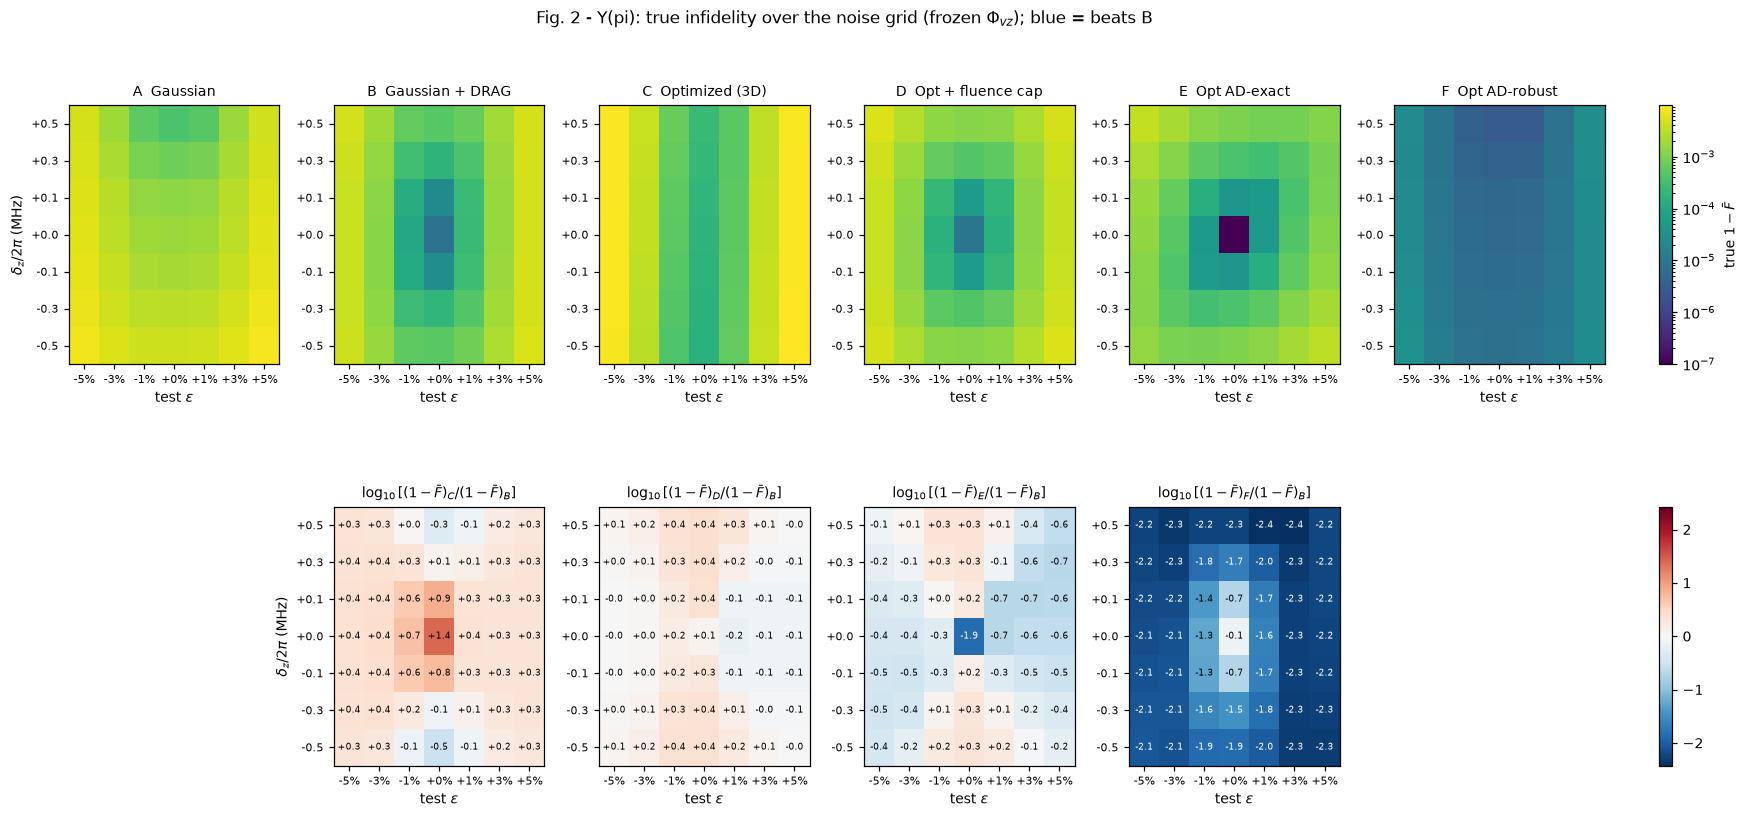

C beats B at 6 of 49 grid points.
D beats B at 18 of 49 grid points.
E beats B at 34 of 49 grid points.
F beats B at 49 of 49 grid points.


In [6]:
vmin = min(s.min() for s in sweeps.values())
vmax = max(s.max() for s in sweeps.values())
ext = [-0.5, len(al.EPS_GRID) - 0.5, -0.5, len(al.DELTA_MHZ_GRID) - 0.5]

def _noise_ticks(ax):
    ax.set_xticks(range(len(al.EPS_GRID)), [f"{e:+.0%}" for e in al.EPS_GRID], fontsize=7)
    ax.set_yticks(range(len(al.DELTA_MHZ_GRID)), [f"{d:+.1f}" for d in al.DELTA_MHZ_GRID], fontsize=7)
    ax.set_xlabel(r"test $\epsilon$")
    ax.grid(False)

RATIO_ARMS = tuple(k for k in ARM_ORDER if k not in ("A", "B"))
n_arms = len(ARM_ORDER)
nrow = 2 if RATIO_ARMS else 1
fig = plt.figure(figsize=(3.0 * n_arms + 0.8, 3.9 * nrow))
gs = fig.add_gridspec(nrow, n_arms + 1, width_ratios=[1] * n_arms + [0.06],
                      hspace=0.55, wspace=0.30)

for i, k in enumerate(ARM_ORDER):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(sweeps[k], origin="lower", aspect="auto", extent=ext,
                   norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=9)
    _noise_ticks(ax)
    if i == 0:
        ax.set_ylabel(r"$\delta_z/2\pi$ (MHz)")
fig.colorbar(im, cax=fig.add_subplot(gs[0, n_arms]), label=r"true $1-\bar F$")

if RATIO_ARMS:
    ratios = {k: np.log10(sweeps[k] / sweeps["B"]) for k in RATIO_ARMS}
    lim = max(np.max(np.abs(r)) for r in ratios.values())
    for i, k in enumerate(RATIO_ARMS):
        ax = fig.add_subplot(gs[1, i + 1])
        im2 = ax.imshow(ratios[k], origin="lower", aspect="auto", extent=ext,
                        cmap="RdBu_r", vmin=-lim, vmax=lim)
        for r in range(ratios[k].shape[0]):
            for c in range(ratios[k].shape[1]):
                ax.text(c, r, f"{ratios[k][r, c]:+.1f}", ha="center", va="center", fontsize=6,
                        color="k" if abs(ratios[k][r, c]) < 0.6 * lim else "w")
        ax.set_title(rf"$\log_{{10}}[(1-\bar F)_{k} / (1-\bar F)_B]$", fontsize=9)
        _noise_ticks(ax)
        if i == 0:
            ax.set_ylabel(r"$\delta_z/2\pi$ (MHz)")
    fig.colorbar(im2, cax=fig.add_subplot(gs[1, n_arms]))

fig.suptitle(f"Fig. 2 - {al.GATE.name}: true infidelity over the noise grid "
             r"(frozen $\Phi_{vz}$); blue = beats B", y=0.99)
plt.show()

for k in RATIO_ARMS:
    print(f"{k} beats B at {int((ratios[k] < 0).sum())} of {ratios[k].size} grid points.")

### Fig. 3 — the $\epsilon$ slice at $\delta_z = 0$

Solid = measured. Dashed = the budget's own prediction, i.e. $C_3$ rescaled to each
$\epsilon$ (exactly quadratic in $\epsilon$).

Arms A and B share the dashed curve: $C_3$ is a property of the design curve, and DRAG
only changes how that curve is played. The right panel is measured/predicted — how far
off the surrogate is, per arm.

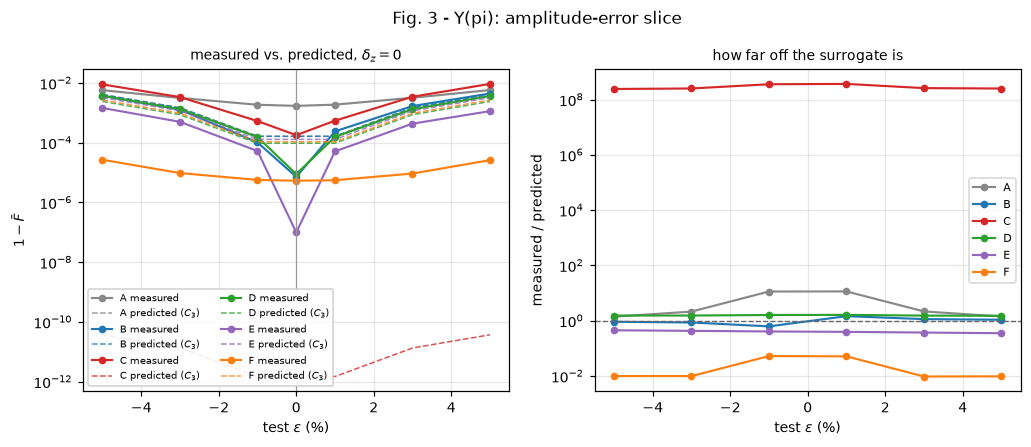

A: 1-F(+5%) = 5.8316e-03   1-F(-5%) = 5.7611e-03   asymmetry = 1.012
B: 1-F(+5%) = 4.4529e-03   1-F(-5%) = 3.7688e-03   asymmetry = 1.182
C: 1-F(+5%) = 9.3499e-03   1-F(-5%) = 9.0003e-03   asymmetry = 1.039
D: 1-F(+5%) = 3.6587e-03   1-F(-5%) = 3.7146e-03   asymmetry = 0.985
E: 1-F(+5%) = 1.1467e-03   1-F(-5%) = 1.4614e-03   asymmetry = 0.785
F: 1-F(+5%) = 2.6188e-05   1-F(-5%) = 2.6922e-05   asymmetry = 0.973


In [7]:
i0 = int(np.where(al.DELTA_MHZ_GRID == 0.0)[0][0])
fig, (ax, axr) = plt.subplots(1, 2, figsize=(11, 3.8))

nz = al.EPS_GRID != 0.0  # C3 is exactly 0 at eps = 0 and has no place on a log axis
for k in ARM_ORDER:
    ax.semilogy(al.EPS_GRID * 100, sweeps[k][i0], "o-", color=al.ARM_COLORS[k],
                lw=1.4, ms=4, label=f"{k} measured")
    pred = al.c3_prediction(arms[k])
    ax.semilogy(al.EPS_GRID[nz] * 100, pred[nz], "--", color=al.ARM_COLORS[k],
                lw=1.0, alpha=0.8, label=f"{k} predicted ($C_3$)")
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel(r"test $\epsilon$ (%)"); ax.set_ylabel(r"$1-\bar F$")
ax.set_title(r"measured vs. predicted, $\delta_z=0$", fontsize=9)
ax.legend(fontsize=6.5, ncol=2, loc="lower left", framealpha=0.9)

for k in ARM_ORDER:
    s = sweeps[k][i0]
    pred = al.c3_prediction(arms[k])
    axr.semilogy(al.EPS_GRID[nz] * 100, s[nz] / pred[nz], "o-", color=al.ARM_COLORS[k],
                 lw=1.4, ms=4, label=k)
axr.axhline(1.0, color="0.4", ls="--", lw=0.9)
axr.set_xlabel(r"test $\epsilon$ (%)"); axr.set_ylabel("measured / predicted")
axr.set_title("how far off the surrogate is", fontsize=9)
axr.legend(fontsize=7)
fig.suptitle(f"Fig. 3 - {al.GATE.name}: amplitude-error slice", y=1.02)
plt.show()

j = int(np.where(al.EPS_GRID == 0.05)[0][0])
jm = int(np.where(al.EPS_GRID == -0.05)[0][0])
for k in ARM_ORDER:
    s = sweeps[k][i0]
    print(f"{k}: 1-F(+5%) = {s[j]:.4e}   1-F(-5%) = {s[jm]:.4e}   "
          f"asymmetry = {s[j]/s[jm]:.3f}")

## Fig. 4 — surrogate vs. truth along the optimization

Each optimized arm's recorded run checkpointed every 100 iterations. The optimizer only
ever saw the surrogate; the true infidelity is recomputed here offline from each
checkpoint's coefficients, with $\Phi_{\rm vz}$ re-fitted at that iterate as a real
calibration would be.

Bottom panel: the diagnostics — fluence over $F_0$, $\max|\tau|$, peak utilisation — so
whatever correlates with a turnaround is visible right next to it.

checkpoint_trace(20260810_F06b_fluence_cap2_mi20000): dropped 3 checkpoint(s) violating the c1 entry ticket (iters [100, 200, 300])


checkpoint_trace(20260810_F06e_adexact_construction_r2): dropped 1 checkpoint(s) violating the c1 entry ticket (iters [100])


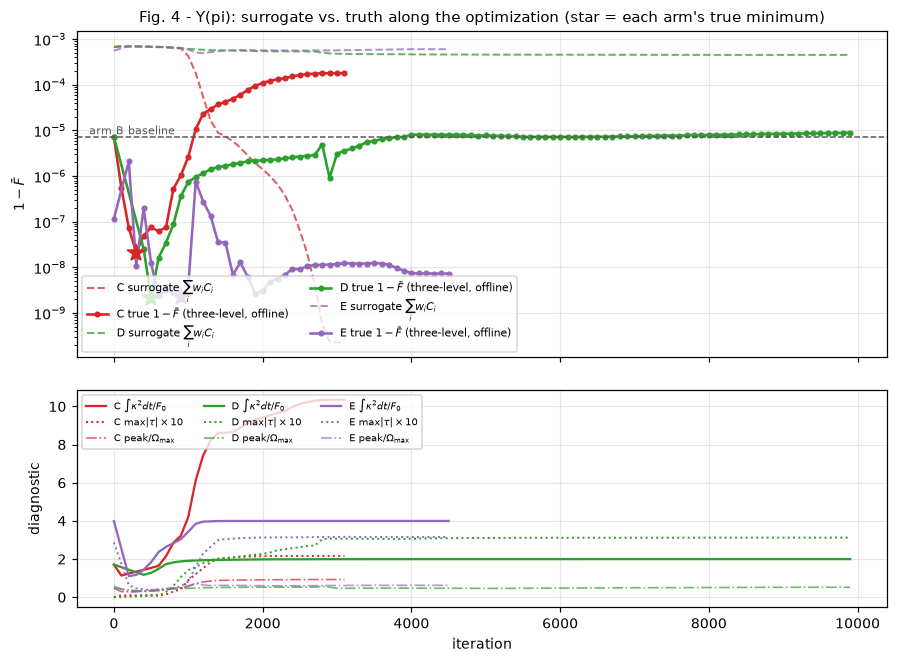

C: true minimum 2.1118e-08 at iter 300 of 3100; final 1.7954e-04; final fluence 10.36 F0
D: true minimum 2.1177e-09 at iter 500 of 9900; final 8.9154e-06; final fluence 2.00 F0
E: true minimum 2.2058e-09 at iter 900 of 4500; final 7.3302e-09; final fluence 4.00 F0


In [8]:
TRACE_ARMS = tuple(k for k in ("C", "D", "E") if k in ARM_ORDER)
if not TRACE_ARMS:
    print("no optimized arm has a recorded run yet - Fig. 4 needs at least one.")
else:
    traces = {k: al.checkpoint_trace(k) for k in TRACE_ARMS}

    fig, (ax, axd) = plt.subplots(2, 1, figsize=(9.5, 6.8), sharex=True,
                                  gridspec_kw={"height_ratios": [1.5, 1.0], "hspace": 0.12})
    for k in TRACE_ARMS:
        tr, col = traces[k], al.ARM_COLORS[k]
        ax.semilogy(tr["iter"], tr["surrogate_total"], "--", lw=1.3, color=col, alpha=0.75,
                    label=rf"{k} surrogate $\sum_i w_i C_i$")
        ax.semilogy(tr["iter"], tr["true_infidelity"], "-o", lw=1.7, ms=3.0, color=col,
                    label=rf"{k} true $1-\bar F$ (three-level, offline)")
        kmin = int(np.argmin(tr["true_infidelity"]))
        ax.plot(tr["iter"][kmin], tr["true_infidelity"][kmin], "*", ms=12, color=col, zorder=5)
    ax.axhline(rows["B"]["baseline_infidelity"], ls="--", lw=1.0, color="0.35")
    ax.text(0.01, rows["B"]["baseline_infidelity"], " arm B baseline",
            transform=ax.get_yaxis_transform(), va="bottom", ha="left", fontsize=7, color="0.35")
    ax.set_ylabel(r"$1-\bar F$")
    ax.set_title(f"Fig. 4 - {al.GATE.name}: surrogate vs. truth along the optimization "
                 "(star = each arm's true minimum)", fontsize=10)
    ax.legend(fontsize=7, loc="lower left", ncol=2)

    for k in TRACE_ARMS:
        tr, col = traces[k], al.ARM_COLORS[k]
        axd.plot(tr["iter"], tr["fluence_over_floor"], "-", lw=1.5, color=col,
                 label=rf"{k} $\int\kappa^2dt / F_0$")
        axd.plot(tr["iter"], tr["max_abs_tau"] * 10, ":", lw=1.3, color=col,
                 label=rf"{k} $\max|\tau|\times10$")
        axd.plot(tr["iter"], tr["peak_frac"], "-.", lw=1.1, color=col, alpha=0.7,
                 label=rf"{k} peak/$\Omega_{{\max}}$")
    axd.set_xlabel("iteration"); axd.set_ylabel("diagnostic")
    axd.legend(fontsize=6.5, ncol=3, loc="upper left")
    plt.show()

    for k in TRACE_ARMS:
        tr = traces[k]
        kmin = int(np.argmin(tr["true_infidelity"]))
        print(f"{k}: true minimum {tr['true_infidelity'][kmin]:.4e} at iter "
              f"{int(tr['iter'][kmin])} of {int(tr['iter'][-1])}; final "
              f"{tr['true_infidelity'][-1]:.4e}; final fluence "
              f"{tr['fluence_over_floor'][-1]:.2f} F0")

## 5. Covariance check — the point of this folder

Every arm here is the corresponding X-axis arm played with the drive phase advanced by
$\phi_{\rm axis} = \pi/2$. The three-level model is covariant under that rotation
(conjugation by $e^{i\phi N}$, $N=\mathrm{diag}(0,1,2)$): the detuning term commutes
with $N$, the quasi-static $\delta_z$ couples through an operator proportional to $N$,
and the amplitude error is a scalar. So every number above **must** equal the
$X$-gate's, point for point.

This cell checks that instead of assuming it. It is also the tripwire: the day the model
grows an IQ imbalance or a quadrature-dependent channel, this check fails and the folder
has to switch to `solve_mode="independent"`.

The same check runs from the command line: `python ../_gatelib/check_covariance.py Ypi`

In [9]:
for k in ARM_ORDER:
    r = al.covariance_check(k)
    costs = "  ".join(f"{c}:{r['cost_rel_diffs'][c]:.1e}" for c in ("c1", "c2", "c3", "c4"))
    print(f"arm {k}: 1-Fbar {r['baseline_here']:.6e} vs {r['source_gate']} "
          f"{r['baseline_there']:.6e}   abs {r['baseline_abs_diff']:.1e}")
    print(f"        sweep max abs diff {r['sweep_max_abs_diff']:.1e}   cost rel diffs  {costs}")
    print(f"        phi_vz refit spread {r['phi_vz_abs_diff']:.1e} rad (calibration noise, "
          f"not part of the verdict)")

print("\nThe rotation is exact to machine precision: C1-C3 agree to 0.0, C4 to ~1e-12 "
      "relative, and every infidelity to ~1e-15 absolute. Anything materially above that "
      "is a bug in the rotation plumbing, or a sign the model has stopped being covariant "
      "- in which case this folder must switch to solve_mode='independent'.")


arm A: 1-Fbar 1.718533e-03 vs X(pi) 1.718533e-03   abs 1.4e-15
        sweep max abs diff 4.0e-15   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:0.0e+00
        phi_vz refit spread 3.7e-08 rad (calibration noise, not part of the verdict)


arm B: 1-Fbar 7.231667e-06 vs X(pi) 7.231667e-06   abs 4.9e-15
        sweep max abs diff 2.5e-15   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:1.1e-12
        phi_vz refit spread 3.1e-08 rad (calibration noise, not part of the verdict)


arm C: 1-Fbar 1.808614e-04 vs X(pi) 1.808614e-04   abs 3.6e-15
        sweep max abs diff 3.3e-15   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:1.6e-11
        phi_vz refit spread 3.8e-13 rad (calibration noise, not part of the verdict)


arm D: 1-Fbar 9.008817e-06 vs X(pi) 9.008817e-06   abs 3.1e-15
        sweep max abs diff 3.4e-15   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:1.5e-13
        phi_vz refit spread 2.9e-08 rad (calibration noise, not part of the verdict)


arm E: 1-Fbar 3.310605e-08 vs X(pi) 3.310605e-08   abs 1.0e-15
        sweep max abs diff 3.8e-15   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:1.3e-14
        phi_vz refit spread 1.1e-12 rad (calibration noise, not part of the verdict)


arm F: 1-Fbar 5.354253e-06 vs X(pi) 5.354253e-06   abs 4.4e-15
        sweep max abs diff 2.8e-15   cost rel diffs  c1:0.0e+00  c2:0.0e+00  c3:0.0e+00  c4:1.5e-14
        phi_vz refit spread 5.9e-13 rad (calibration noise, not part of the verdict)

The rotation is exact to machine precision: C1-C3 agree to 0.0, C4 to ~1e-12 relative, and every infidelity to ~1e-15 absolute. Anything materially above that is a bug in the rotation plumbing, or a sign the model has stopped being covariant - in which case this folder must switch to solve_mode='independent'.


## 6. Export

120-point CSVs (`time_ns, Omega_x_rad_per_ns, Omega_y_rad_per_ns`, the F07 schema),
coefficient JSONs for exact regeneration, and a manifest. The sampling loss is the
120-point infidelity over the fine-grid one — reported, not thresholded.

In [10]:
manifest = al.export_arms(arms, rows)
print(json.dumps(manifest["arms"], indent=1))
print("\nfiles:")
for p in sorted((Path.cwd() / "waveforms").iterdir()):
    print(f"  {p.relative_to(Path.cwd())}  ({p.stat().st_size} bytes)")

{
 "A": {
  "name": "Gaussian",
  "layer": "planar",
  "csv": "waveforms/A_gaussian_120pt.csv",
  "json": "waveforms/A_gaussian.json",
  "run_id": null,
  "infidelity_120pt": 0.0017185320709343088,
  "infidelity_fine": 0.0017185331283666727,
  "sampling_loss_ratio": 0.9999993846889847
 },
 "B": {
  "name": "Gaussian + DRAG",
  "layer": "planar_drag",
  "csv": "waveforms/B_gaussian_drag_120pt.csv",
  "json": "waveforms/B_gaussian_drag.json",
  "run_id": null,
  "infidelity_120pt": 7.229761350591168e-06,
  "infidelity_fine": 7.231667204177228e-06,
  "sampling_loss_ratio": 0.9997364572328552
 },
 "C": {
  "name": "Optimized (3D)",
  "layer": "general",
  "csv": "waveforms/C_optimized_120pt.csv",
  "json": "waveforms/C_optimized.json",
  "run_id": "20260808_F06min_gaussian3d_construction",
  "infidelity_120pt": 0.00017645114850628474,
  "infidelity_fine": 0.00018086139869633033,
  "sampling_loss_ratio": 0.9756153041951727
 },
 "D": {
  "name": "Opt + fluence cap",
  "layer": "general",
  "

## 7. What the run says

Fill in from the numbers above, not in advance:

* §5 must read PASS. If it does not, nothing else on this page is trustworthy.
* Fig. 1 is the only figure that should look different from the $X(\pi)$ folder's.
* Everything else is inherited; do not report it as an independent confirmation of the
  physics, because it is not — it is the same run, relabelled.